### Imports
    

In [95]:
import os
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic
from langchain_neo4j import Neo4jGraph
from neo4j import GraphDatabase
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage
from typing import TypedDict, List, Annotated
import operator
import pandas as pd
from langsmith import Client
from langgraph.checkpoint.memory import MemorySaver
from prompts import psychology_guidelines, schema_docs, system_prompt, neo4j_cs
import json
from datetime import datetime
load_dotenv()
langsmith_client = Client()

### Connect to Neo4j and setup Anthropic


In [96]:
try:
    driver = GraphDatabase.driver(
        os.environ.get("NEO4J_URI"),
        auth=(os.environ.get("NEO4J_USERNAME"), os.environ.get("NEO4J_PASSWORD"))
    )

    driver.verify_connectivity()
    print("Neo4j connection successful")
    
    graph = Neo4jGraph(
        url=os.environ.get("NEO4J_URI"),
        username=os.environ.get("NEO4J_USERNAME"),
        password=os.environ.get("NEO4J_PASSWORD"),
        timeout=30  
    )
    try:
        CACHED_SCHEMA = graph.get_schema
        print("Schema cached successfully")
        print(f"Schema preview: {str(CACHED_SCHEMA)[:200]}...")
    except Exception as schema_error:
        print(f"Could not cache schema: {schema_error}")
        CACHED_SCHEMA = None

    llm = ChatAnthropic(
        model="claude-3-5-haiku-latest",
        temperature=0.3,
        anthropic_api_key=os.getenv("ANTHROPIC_API_KEY"),
        max_tokens=4000
    )
    
    print("LLM initialized successfully")

except Exception as e:
    print(f"Setup failed: {e}")
    raise

Neo4j connection successful
Schema cached successfully
Schema preview: Node properties:
event_record {id: INTEGER, event_sub_type_id: FLOAT, on_scene_time: FLOAT, event_severity: STRING, source: STRING, event_type_id: INTEGER, is_obsolete: INTEGER, is_congt: INTEGER, end...
LLM initialized successfully
Schema cached successfully
Schema preview: Node properties:
event_record {id: INTEGER, event_sub_type_id: FLOAT, on_scene_time: FLOAT, event_severity: STRING, source: STRING, event_type_id: INTEGER, is_obsolete: INTEGER, is_congt: INTEGER, end...
LLM initialized successfully


### Tools setup


In [97]:
@tool
def run_cypher_query(query: str) -> str:
    """Execute a Cypher query against the Neo4j database to retrieve road network data.
    
    Use this tool when you need to:
    - Find specific roads, intersections, or traffic data
    - search for past event details either by the link id or the event id
    - Query relationships between road segments
    - Get traffic incident information
    - Analyze road network connectivity
    - Search for alternative route
    - Searching for VMS (FOR THE DISTANCE PLEASE GET FROM vms_range_get output)
    
    Args:
        query: A valid Cypher query string
        
    Returns:
        Query results as a string (limited to 50 records)
    """
    try:
        with driver.session() as session:
            result = session.run(query)
            records = [dict(record) for record in result]
            return str(records[:50])
    except Exception as e:
        return f"Query error: {str(e)}"

@tool 
def get_schema() -> str:
    """
    Get the Neo4j database schema including all node labels, relationship types and properties
    Use this tool FIRST before running any Cypher queries to understand:
    - What node labels exist (e.g., Road, Intersection, TrafficIncident)
    - What relationship types are available (e.g., CONNECTS_TO, HAS_INCIDENT)
    - What properties each node/relationship has
    
    This ensures your Cypher queries use correct labels, properties, and relationships
    that actually exist in the database to avoid query errors.
    
    Returns:
        Complete database schema information
    """
    # Removed duplicate print statement
    try:
        if CACHED_SCHEMA is not None:
            return str(CACHED_SCHEMA)
        else:
            schema_info = graph.get_schema
            return str(schema_info)
    except Exception as e:
        return f"Schema error: {str(e)}"

@tool 
def generate_response_plan(context: str) -> str:
    """
    Generates a response plan based on the incident context retrieved from the knowledge graph
    Input: context (string) - Comprehensive context including incident details, VMS data importantly the id,
    event with their respective plan and plan command history to provide context.
    Returns: the explicit JSON formatted response plan with actions and VMS commands not the summary.
    """
    
    # Extract VMS data from context to ensure all are used
    import re
    vms_matches = re.findall(r"'EQT_NO': '([^']+)'|\"EQT_NO\": \"([^\"]+)\"|'EQT_EXT_ID': '([^']+)'|\"EQT_EXT_ID\": \"([^\"]+)\"", context)
    vms_list = []
    for match in vms_matches:
        vms_id = match[0] or match[1] or match[2] or match[3]
        if vms_id and vms_id not in vms_list:
            vms_list.append(vms_id)
    
    vms_requirement = f"\n\nCRITICAL REQUIREMENT: You MUST create traffic_management_actions for ALL {len(vms_list)} VMS devices found in the context: {vms_list}\nEach VMS must have its own traffic_management_action entry with its specific EQT_NO." if vms_list else ""

    prompt = f"""
    You are an expert in traffic management specializing in creating response plans.
    Based on traffic incident information and psychological principles, generate a comprehensive response plan.
    
    Context: {context}
    {psychology_guidelines}
    {vms_requirement}
    
    RESPONSE PLAN FORMAT:
    Generate a response plan in the following JSON format:

    {{
        "plan_type": "Traffic Management Plan",
        "priority": "High/Medium/Low",
        "estimated_duration": "X minutes/hours",
        "traffic_management_actions": [
            {{
                "eqt_no": "VMS_EQUIPMENT_ID (from EQT_NO or EQT_EXT_ID)",
                "message_line_1": "Primary message (max 20 chars)",
                "message_line_2": "Secondary message (max 20 chars)",
                "display_duration": "X minutes",
                "distance": "distance from event in meters",
                "psychological_rationale": "Why this message is psychologically effective",
                "behavioral_goal": "Desired driver behavior",
                "urgency_level": "High/Medium/Low based on distance and severity",
                "reasoning": "Give your reasoning for all of the above, why this duration etc."
            }},
            
            {{
                "action": "Specific action to take",
                "location": "Where to implement",
                "resources_needed": "What resources are required",
                "timing": "When to implement"
            }}
        ],
        "messaging_strategy": {{
            "primary_emotion": "Urgency/Caution/Information",
            "cognitive_approach": "Simple/Clear/Direct",
            "behavioral_target": "Slow down/Merge/Avoid area"
        }},
        "emergency_response": {{
            "agencies_to_notify": [
                {{
                    "agency": "Police/Fire Services/Emergency Medical Services/Road Maintenance/Traffic Control",
                    "priority": "Immediate/High/Medium/Low",
                    "reason": "Specific reason for notification",
                    "contact_method": "Emergency dispatch/Direct call/Radio",
                    "resources_requested": "Number of units/personnel needed"
                }}
            ],
            "coordination_requirements": "How agencies should coordinate",
            "scene_management": "Who takes lead and scene control responsibilities"
        }},
        "justification": "Psychology-based explanation of messaging choices"
    }}
    
    MANDATORY VMS USAGE REQUIREMENTS:
    1. MUST include traffic_management_actions for ALL VMS devices listed above
    2. Each VMS device MUST have its own dedicated traffic_management_action entry
    3. Use the exact EQT_NO from the context data
    4. Tailor message content based on distance from incident (closer = more urgent)
    5. Ensure messages follow the 20-character limit per line
    6. Do NOT combine multiple VMS into a single action entry
    
    RECOMMENDED ACTIONS GUIDELINES:
    1. Generate additional actions that could aid in controlling the event
    2. Provide a priority level to recommended event
    3. Give clear reasoning and thought behind each event
    4. State the required equipment and personnel to carry out said action
    5. Recommend at least 2 actions

    EMERGENCY RESPONSE AGENCY GUIDELINES:
    1. POLICE: Required for all accidents with injuries, traffic control, investigation
    2. FIRE SERVICES: Required for vehicle fires, fuel spills, extraction operations
    3. EMERGENCY MEDICAL SERVICES: Required for any injuries, medical emergencies
    4. ROAD MAINTENANCE: Required for debris cleanup, road surface damage, barrier repairs
    5. TRAFFIC CONTROL: Required for major incidents affecting multiple lanes or extended duration
    6. TOWING SERVICES: Required for vehicle removal, clearance operations
    
    PRIORITY LEVELS:
    - Immediate: Life-threatening situations, major blockages during rush hour
    - High: Injuries present, significant traffic impact, hazardous conditions
    - Medium: Property damage only, minor traffic disruption, routine cleanup
    - Low: Minor incidents, off-peak hours, minimal impact
    
    PSYCHOLOGICAL MESSAGING RULES:
    1. Use psychology guidelines above to craft messages
    2. Consider time of day (0800 = rush hour psychology)
    3. Match message urgency to distance from incident
    4. Use action-oriented language that triggers immediate response
    5. Avoid cognitive overload - keep messages simple and clear
    6. Consider emotional state of stressed commuters

    Generate practical VMS messages that will effectively influence driver behavior and prevent secondary accidents.
    Remember: You MUST use ALL {len(vms_list)} VMS devices provided in the context.
    """
    
    try:
        response = llm.invoke(prompt)
        # Keep only one essential print statement
        print("Response plan generated - routing to human review")
        return response.content
    except Exception as e:
        return f"Error generating psychology-based response plan: {str(e)}"
    
@tool
def extract_event_data(event_description: str) -> str:
    """
    Extract structured event data from user input or event updates.
    
    Args:
        event_description: Description of the traffic event or incident
    
    Returns:
        JSON with structured event data for comparison
    """
    # Removed duplicate print statement
    prompt = f"""
    Extract structured data from this traffic event description:
    CHECK THE ROAD TYPE AS THIS WILL HAVE SIGNIFICANT IMPACT ON THE PLAN
    MUST TAKE INTO CONSIDERATION OF THE ROAD TYPE
    EVENT DESCRIPTION: {event_description}
    
    Return the data in this JSON format:
    {{
        "event_id": "unique identifier if mentioned or generate one",
        "link_id": "road link ID if mentioned",
        "incident_type": "accident/breakdown/roadworks/weather/other",
        "severity": "high/medium/low",
        "blocked_lanes": ["list", "of", "blocked", "lanes"],
        "queue_length": "length in meters (number only)",
        "time": "time in HHMM format",
        "duration_minutes": "how long incident has been active (number only)",
        "location_description": "human readable location",
        "additional_hazards": ["list", "of", "any", "additional", "hazards"],
        "weather_conditions": "if mentioned",
        "traffic_volume": "high/medium/low if assessable from time/location"
        "road_type": "major_roads/motorways/other_major_roads/secondary_roads/local_connecting_roads/local_roads_high_importance/local_roads/local_roads_minor_importance/other_roads (taken from incident link)"
    }}
    
    If information is not provided, use null for that field.
    Extract only factual information from the description.
    """
    
    try:
        response = llm.invoke(prompt)
        return response.content
    except Exception as e:
        return f"Error extracting event data: {str(e)}"

@tool
def analyze_event_changes(event_id: str, event_data: str) -> str:
    """
    Analyze changes between current and previous event states to determine if a response plan update is needed.
    
    Args:
        event_data: Current event data including incident details, lane closures, queue lengths
    
    Returns:
        JSON with analysis of changes and recommendation on whether to update the response plan
    """
    previous_data = None
    # Removed duplicate print statement
    
    try:
        check_query = """
        MATCH (e:event_record {event_id: $event_id})
        RETURN e.event_id AS event_id
        """

        with driver.session() as session:
            existing = session.run(check_query, event_id=event_id).single()

            if existing:
                # Only print once for existing events
                print(f"Event {event_id}: Analyzing changes for ongoing event")

                result = session.run(
                    """
                    MATCH (n)
                    WHERE n.event_id = $event_id
                    RETURN n
                    """,
                    event_id=event_id
                )

                previous_data = [dict(record["n"]) for record in result]
                # Removed duplicate print of previous_data

            else:
                print(f"Event {event_id}: New event detected, generating response plan")
                previous_data = None


        prompt = f"""
        You are an expert traffic management analyst. Compare the current event data with previous data
        and determine if changes warrant updating the response plan.

        CURRENT EVENT DATA:
        {event_data}

        PREVIOUS EVENT DATA:
        {previous_data or "No previous data available - this is a new event."}

        ANALYSIS RULES:
        1. Lane Blockages: ANY change in lane closures = HIGH significance, update required
        2. Queue Length: >500m change = HIGH significance, 200-500m = MEDIUM, <200m = LOW  
        3. Incident Severity: ANY severity change = HIGH significance, update required
        4. Time Changes: >2 hours elapsed OR crossing rush hour periods = MEDIUM significance
        5. Additional Hazards: NEW hazards reported = HIGH significance, update required

        UPDATE DECISION LOGIC:
        - If ANY change has HIGH significance → update_required = TRUE
        - If 2+ changes have MEDIUM significance → update_required = TRUE  
        - If ALL changes are LOW significance → update_required = FALSE
        - If this is a new event (no previous data) → update_required = TRUE

        Return your analysis in the following JSON format:

        {{
            "event_id": "{event_id}",
            "is_update": {str(previous_data is not None).lower()},
            "update_required": true/false,
            "significant_changes": [
                {{
                    "metric": "lane_blockage/queue_length/severity/time/hazards",
                    "previous_value": "previous value if available",
                    "current_value": "current value",
                    "significance": "high/medium/low",
                    "reasoning": "Why this change matters or doesn't"
                }}
            ],
            "critical_changes": true/false,
            "recommendation": "Update response plan / No update needed",
            "explanation": "Detailed explanation based on the UPDATE DECISION LOGIC above"
        }}

        IMPORTANT: 
        - DO NOT return anything other than the JSON output 
        - NO additional explanations outside of JSON are require
        - Be strict about update_required - only set to TRUE if genuinely significant changes occurred
        - If no meaningful changes, set update_required = FALSE to avoid unnecessary plan generation
        - For new events (no previous data), always set update_required = TRUE
        """

        response = llm.invoke(prompt)
        return response.content

    except Exception as e:
        return f"Error analyzing event changes: {str(e)}"

    
@tool
def store_event_details(event_data: str, event_id: str, graph_schema: str = None) -> str:
    """
    Stores event details as an `event_record` node in Neo4j.

    Args:
        event_data: JSON string of structured event data.
        event_id: Unique identifier for the event.
        graph_schema: JSON string of the graph schema (optional, will use cached schema if not provided)

    Returns:
        Confirmation of storage with event ID.
    """
    try:
        # Removed duplicate print statement
        # Use provided schema or fall back to cached schema
        schema_to_use = graph_schema if graph_schema else str(CACHED_SCHEMA) if CACHED_SCHEMA else "Schema not available"
        
        prompt = f"""
        You are an expert in generating Neo4j Cypher queries.
        UTILIZE MERGE NOT CREATE FUNCTION WHEN UPDATING

        Use the schema below to:
        1. Create an `event_record` node.
        2. Use only the properties listed under the `event_record` node in the schema.
        3. Replace missing or unknown values with null.
        4. Add in additional property road_type taken from the incident link
        5. Use '{event_id}' as the event_id.
        6. Add a `created_timestamp` with datetime().
        7. End with: RETURN e.event_id AS event_id

        IMPORTANT RELATIONSHIP CREATION:
        - After creating the event_record, find the road link using the link_id from the event data
        - Create a CONNECTED_TO relationship: (event_record)-[:LOCATED_AT]->(road_link)
        - The road link should be matched by its link_id property (or similar identifier)

        SCHEMA: {schema_to_use}

        EVENT DATA:
        {event_data}

        Output ONLY a valid Cypher query. Do NOT include any explanation.
        """

        response = llm.invoke(prompt)

        with driver.session() as session:
            result = session.run(response.content)
            record = result.single()
            
            return f"Event stored successfully with ID: {record['event_id']}"


    except Exception as e:
        return f"Error storing event: {str(e)}" 


# Can edit the cypher to add more properties to plan node
@tool
def store_event_plan(response_plan: str, event_id: str, vms_used: list = None) -> str:
    """
    Stores a response plan as an `event_plan` node in Neo4j and links it to the corresponding `event_record`.

    Args:
        response_plan: JSON string of the plan details.
        event_id: ID of the associated event.
        vms_used: list of EQT_NO of the vms used in the plan (optional, will extract from plan if not provided)
        graph_schema: JSON string of the graph schema (optional, will use cached schema if not provided)

    Returns:
        Confirmation message with plan ID if available.
    """
    # Removed duplicate print statement
    try:
        # Extract VMS IDs from response plan if not provided
        if not vms_used:
            try:
                import json
                plan_data = json.loads(response_plan)
                vms_used = []
                
                # Extract from traffic_management_actions
                if 'traffic_management_actions' in plan_data:
                    for action in plan_data['traffic_management_actions']:
                        if 'eqt_no' in action and action['eqt_no']:
                            vms_used.append(action['eqt_no'])
                
            except Exception as e:
                vms_used = []

        # Create the main event_plan node first
        main_query = f"""
        MERGE (ep:event_plan {{event_id: '{event_id}'}})
        ON CREATE SET 
            ep.id = toString(randomUUID()),
            ep.created_timestamp = datetime(),
            ep.plan_status = 'active'
        SET ep.plan_details = $plan_data
        WITH ep
        MATCH (er:event_record {{event_id: '{event_id}'}})
        MERGE (er)-[:HAS_PLAN]->(ep)
        RETURN ep.id AS plan_id
        """

        with driver.session() as session:
            # Execute main query to create event_plan and link to event_record
            result = session.run(main_query, plan_data=response_plan)
            record = result.single()
            plan_id = record.get('plan_id', 'unknown') if record else 'unknown'
            
            # Create VMS relationships separately if VMS IDs exist
            vms_linked = 0
            if vms_used:
                for vms_id in vms_used:
                    try:
                        vms_query = """
                        MATCH (ep:event_plan {event_id: $event_id}), (vms:VMS {EQT_NO: $vms_id})
                        MERGE (vms)-[:CONTROLS_VMS]->(ep)
                        RETURN vms.EQT_NO AS linked_vms
                        """
                        vms_result = session.run(vms_query, event_id=event_id, vms_id=vms_id)
                        if vms_result.single():
                            vms_linked += 1
                    except Exception as vms_error:
                        pass
            
            return f"Response plan stored successfully with ID: {plan_id}. VMS linked: {vms_linked}/{len(vms_used)} devices"

    except Exception as e:
        return f"Error storing plan: {str(e)}"

# NEW: Add the missing vms_range_get tool that is referenced in the system prompt
@tool
def vms_range_get(queue_length: int, road_type: str, severity: str) -> str:
    """
    Calculate upstream VMS search distance based on queue length (m), road type, and severity.
    Returns a JSON string: {"search_distance_meters": int}
    """
    try:
        # Safety buffers by road type
        road_type_key = (road_type or "").strip().lower()
        buffers = {
            "motorways": 3000,
            "major roads": 2000,
            "other major roads": 2000,
            "secondary roads": 1500,
            "local connecting roads": 1000,
            "local roads of high importance": 1000,
            "local roads": 1000,
            "local roads of minor importance": 1000,
            "other roads": 1000,
        }
        safety_buffer = buffers.get(road_type_key, 2000)

        sev = (severity or "").strip().lower()
        mult = 1.0
        if sev == "high":
            mult = 1.5
        elif sev == "medium":
            mult = 1.2

        q = int(queue_length or 0)
        base = q + safety_buffer
        dist = int(max(2000, min(10000, base * mult)))


        return json.dumps({"search_distance_meters": dist})
    except Exception as e:
        return json.dumps({"error": str(e)})
    
# Add the tools to the list including the new distance tool
tools = [get_schema, run_cypher_query, generate_response_plan, analyze_event_changes, extract_event_data, vms_range_get, store_event_details, store_event_plan]
tool_node = ToolNode(tools)

### Parsing error handler

In [98]:
def custom_parsing_error_handler(error):
    """Custom handler to see what the LLM actually outputs"""
    print("=" * 50)
    print("PARSING ERROR DETECTED!")
    print("Error message:", str(error))
    print("=" * 50)
    

    error_str = str(error)
    if "Could not parse LLM output:" in error_str:
        # Extract the actual output
        start_idx = error_str.find("Could not parse LLM output:") + len("Could not parse LLM output:")
        end_idx = error_str.find("For troubleshooting")
        if end_idx == -1:
            actual_output = error_str[start_idx:].strip()
        else:
            actual_output = error_str[start_idx:end_idx].strip()
        
        print("ACTUAL LLM OUTPUT:")
        print(actual_output)
        print("=" * 50)
        
        # Return a formatted response
        return f"LLM tried to use tool but format was wrong. Raw output: {actual_output}"
    
    return f"Parsing error: {error}"

### Feedback Processing Agent

In [99]:
# Feedback Processing Agent - specialized for handling human feedback and VMS search requests

# Specialized system prompt for feedback processing
FEEDBACK_AGENT_PROMPT = """
You are a specialized Feedback Processing Agent for traffic incident management systems.

YOUR ROLE:
- Process human feedback on response plans
- Execute VMS search requests with proper workflow
- Generate updated response plans with all found VMS
- Focus ONLY on implementing requested changes

CORE RESPONSIBILITIES:
1. Analyze human feedback to determine the type of request
2. Execute VMS search workflows when requested
3. Generate updated response plans using ALL available VMS
4. Follow the exact sequence for VMS search operations

VMS SEARCH WORKFLOW (MANDATORY SEQUENCE):
When feedback requests VMS search or mentions distances/additional VMS:

STEP 1: Extract event data from context
- Find link_id, queue_length, road_type, severity from previous messages
- Look for extract_event_data results in message history

STEP 2: Calculate search distance
- If feedback specifies distance (e.g., "10000m", "8000m"), use that
- Otherwise use vms_range_get tool with event parameters

STEP 3: Project graph for VMS search
- Use run_cypher_query with project_graph_template
- Replace {link_id} with actual link_id from event data

STEP 4: Execute Dijkstra VMS search
- Use run_cypher_query with dijkstras_search_template  
- Replace {link_id} and {distance} with actual values
- Include existing VMS in exclusion list to find NEW ones

STEP 5: Drop graph projection
- Use run_cypher_query with drop_graph_template

STEP 6: Generate updated response plan
- Use generate_response_plan with ALL context (existing + new VMS)
- Tool will automatically extract and use all VMS found

CRITICAL RULES:
- NEVER skip the VMS search sequence
- ALWAYS follow steps 1-6 in order for VMS requests
- NEVER go directly to generate_response_plan for VMS feedback
- Include ALL VMS (existing + newly found) in final plan
- Extract exact values from context, don't make assumptions

FEEDBACK TYPES:
1. VMS Search: Keywords like "search", "distance", "VMS", "additional", "more"
2. Plan Modification: Changes to messaging, timing, priorities
3. Approval: "approve", "approved", "yes", "ok"

For VMS search requests, you MUST execute the full workflow above.
For other modifications, update the plan directly with requested changes.
For approvals, no action needed - mark as approved.

CONTEXT EXTRACTION:
- Always look for event_id, link_id, queue_length in previous tool results
- Find existing VMS IDs from current response plan
- Use exact database values, never estimate
"""

# Initialize the feedback processing LLM
feedback_llm = ChatAnthropic(
    model="claude-3-5-haiku-latest",
    temperature=0.1,  # Lower temperature for more consistent workflow execution
    anthropic_api_key=os.getenv("ANTHROPIC_API_KEY"),
    max_tokens=4000
)

class FeedbackProcessor:
    def __init__(self):
        self.llm = feedback_llm
        self.tools = tools  # Use the same tools as main agent
        self.llm_with_tools = self.llm.bind_tools(self.tools)
    
    def process_feedback(self, feedback: str, current_plan: str, message_history: List) -> dict:
        """
        Process human feedback and execute appropriate actions
        
        Args:
            feedback: Human feedback text
            current_plan: Current response plan
            message_history: Previous messages for context
        
        Returns:
            dict with processed result and updated plan
        """
        
        # Create context from message history
        context_messages = []
        for msg in message_history[-20:]:  # Last 20 messages for context
            if hasattr(msg, 'content') and msg.content:
                context_messages.append(f"Message: {msg.content[:500]}")
        
        context = "\n".join(context_messages)
        
        # Create the feedback processing prompt
        feedback_prompt = f"""
        {FEEDBACK_AGENT_PROMPT}
        
        HUMAN FEEDBACK TO PROCESS:
        {feedback}
        
        CURRENT RESPONSE PLAN:
        {current_plan}
        
        CONTEXT FROM PREVIOUS MESSAGES:
        {context}
        
        TASK: Process the human feedback and execute the appropriate workflow.
        
        If this is a VMS search request:
        1. Extract event details from context
        2. Execute the VMS search workflow (Steps 1-6 above)
        3. Generate updated response plan with ALL VMS
        
        If this is a plan modification:
        1. Update the response plan with requested changes
        2. Maintain all safety and psychological principles
        
        If this is an approval:
        1. Return approval confirmation
        
        Start by analyzing the feedback type and then execute the appropriate workflow.
        """
        
        try:
            # Process the feedback
            response = self.llm_with_tools.invoke([
                {"role": "system", "content": FEEDBACK_AGENT_PROMPT},
                {"role": "user", "content": feedback_prompt}
            ])
            
            return {
                "success": True,
                "response": response,
                "tool_calls": getattr(response, 'tool_calls', [])
            }
            
        except Exception as e:
            return {
                "success": False,
                "error": str(e),
                "response": None
            }
    
    def execute_tool_sequence(self, tool_calls: List, message_history: List) -> List:
        """
        Execute a sequence of tool calls and return results
        """
        results = []
        
        for tool_call in tool_calls:
            try:
                tool_name = tool_call['name']
                tool_args = tool_call['args']
                
                # Find and execute the tool
                tool_func = None
                for tool in self.tools:
                    if tool.name == tool_name:
                        tool_func = tool
                        break
                
                if tool_func:
                    result = tool_func.invoke(tool_args)
                    results.append({
                        "tool": tool_name,
                        "args": tool_args,
                        "result": result
                    })
                else:
                    results.append({
                        "tool": tool_name,
                        "args": tool_args,
                        "error": f"Tool {tool_name} not found"
                    })
                    
            except Exception as e:
                results.append({
                    "tool": tool_call.get('name', 'unknown'),
                    "error": str(e)
                })
        
        return results

# Initialize the feedback processor
feedback_processor = FeedbackProcessor()

print("Feedback Processing Agent initialized successfully!")
print("- Specialized for VMS search and response plan updates")
print("- Follows strict workflow sequences")
print("- Prevents confusion between main agent and feedback processing")

Feedback Processing Agent initialized successfully!
- Specialized for VMS search and response plan updates
- Follows strict workflow sequences
- Prevents confusion between main agent and feedback processing


### State definition

In [100]:
class GraphState(TypedDict):
    messages: Annotated[List[HumanMessage | AIMessage], operator.add]
    tool_calls: List[dict]
    user_feedback: str
    final_approved: bool
    revision_count: int
    needs_revision: bool
    current_plan: str
    event_history: List[dict]
    event_id: str
    previous_event_state: str
    current_event_state: str
    event_analysis_completed: bool
    update_required: bool
    approved_plan: bool
    response_plan_generated: bool
    event_stored: bool
    plan_stored: bool
    _step_count: int

### Workflow implementation

In [101]:
from langgraph.errors import NodeInterrupt

def should_continue(state: GraphState):
    """Decide whether to continue with tools or end."""
    last_message = state["messages"][-1]
    needs_revision = state.get("needs_revision", False)
    final_approved = state.get("final_approved", False)
    event_stored = state.get("event_stored", False)
    plan_stored = state.get("plan_stored", False)
    event_analysis_completed = state.get("event_analysis_completed", False)
    update_required = state.get("update_required", None)
    step_count = state.get("_step_count", 0)
    user_feedback = state.get("user_feedback", "")

    # Hard limit to prevent infinite loops
    if step_count >= 25:
        print("Maximum step count reached - ending workflow")
        return END

    # Check if storage operations are complete (only after human approval)
    for message in reversed(state["messages"][-20:]):  
        if hasattr(message, 'name') and message.name == "store_event_details":
            if hasattr(message, 'content') and "successfully" in message.content.lower():
                event_stored = True
                break
    
    for message in reversed(state["messages"][-20:]):  
        if hasattr(message, 'name') and message.name == "store_event_plan":
            if hasattr(message, 'content') and "successfully" in message.content.lower():
                plan_stored = True
                break
    
    # If storage is complete AND approved, end the workflow
    if plan_stored and event_stored and final_approved:
        print("Storage completed successfully - ending workflow")
        return END
    
    # Check for event analysis completion and update_required
    for message in reversed(state["messages"][-15:]): 
        if (hasattr(message, 'name') and 
            message.name == "analyze_event_changes" and
            hasattr(message, 'content')):
            event_analysis_completed = True
            try:
                import json
                analysis_result = json.loads(message.content)
                update_required = analysis_result.get("update_required", True)
            except Exception as e:
                update_required = True
            break
        
    # If analysis says no update required, end early
    if event_analysis_completed and update_required == False:
        print("Event analysis complete: No response plan update required - ending workflow")
        return END
    
    # PRIORITY 1: Handle revision cases - route to feedback processor
    if needs_revision and user_feedback and user_feedback.lower() != "approve":
        return "feedback_processor"
    
    # PRIORITY 2: Handle tool calls
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"
    
    # PRIORITY 3: Handle approved plans - continue to storage
    if final_approved:
        return "tools"
    
    # PRIORITY 4: Check if NEW response plan was generated AFTER feedback
    # Only route to human feedback if this is a fresh plan (not when revising)
    if not needs_revision and not user_feedback:
        response_plan_generated = False
        for message in reversed(state["messages"][-5:]):  # Look at recent messages only
            if (hasattr(message, 'name') and 
                message.name == "generate_response_plan" and
                hasattr(message, 'content')):
                response_plan_generated = True
                return "human_feedback"
        
        # Check if AI message contains response plan
        if (hasattr(last_message, 'content') and 
            last_message.content and
            ("plan_type" in last_message.content or "traffic_management_actions" in last_message.content)):
            return "human_feedback"
    
    # PRIORITY 5: Continue if analysis requires update but plan not generated
    if not event_analysis_completed:
        return "tools"
    
    if update_required == True:
        return "tools"
    
    return "tools"


def route_after_human_feedback(state: GraphState):
    """Route after human feedback"""
    final_approved = state.get("final_approved", False)
    user_feedback = state.get("user_feedback", "")
    
    if final_approved:
        return "agent"  
    else:
        return "feedback_processor"  # Route to specialized feedback processor


def call_model(state: GraphState):
    """Call the main LLM with the current state"""
    
    user_feedback = state.get("user_feedback", "")
    needs_revision = state.get("needs_revision", False)
    current_plan = state.get("current_plan", "")
    final_approved = state.get("final_approved", False)
    step_count = state.get("_step_count", 0)

    # Increment step counter
    step_count += 1

    system_message = {"role": "system", "content": system_prompt}

    valid_messages = []
    for msg in state["messages"]:
        if hasattr(msg, 'content') and msg.content and str(msg.content).strip():
            valid_messages.append(msg)
        elif hasattr(msg, 'tool_calls') and msg.tool_calls:
            valid_messages.append(msg)
    
    messages = [system_message] + valid_messages
    
    if final_approved and current_plan:
        event_stored = False
        plan_stored = False
        
        for message in reversed(state["messages"][-30:]):
            if (hasattr(message, 'name') and message.name == "store_event_details" and 
                hasattr(message, 'content') and "successfully" in message.content.lower()):
                event_stored = True
            if (hasattr(message, 'name') and message.name == "store_event_plan" and
                hasattr(message, 'content') and "successfully" in message.content.lower()):
                plan_stored = True
        
        if not event_stored and not plan_stored:
            storage_prompt = """
            The response plan has been approved. Store the event details first using store_event_details tool.
            Extract the event_id and event data from previous messages.
            """
        elif event_stored and not plan_stored:
            storage_prompt = f"""
            Event details have been stored successfully. Now store the approved response plan using store_event_plan tool.
            
            APPROVED PLAN TO STORE:
            {current_plan}
            """
        else:
            # Both are done, shouldn't reach here
            storage_prompt = "Both event and plan have been stored successfully."
        
        storage_message = HumanMessage(content=storage_prompt)
        messages.append(storage_message)

    llm_with_tools = llm.bind_tools(tools)
    
    response = llm_with_tools.invoke(messages)
    
    return {
        "messages": [response],
        "needs_revision": False,  
        "user_feedback": "",
        "final_approved": final_approved,  
        "current_plan": current_plan,
        "_step_count": step_count
    }


def feedback_processor_node(state: GraphState):
    """Dedicated feedback processing node using the specialized agent"""
    
    user_feedback = state.get("user_feedback", "")
    current_plan = state.get("current_plan", "")
    messages = state.get("messages", [])
    
    print(f"🔄 Feedback Processor: Processing feedback: {user_feedback[:100]}...")
    
    try:
        # Create context from message history
        context_messages = []
        for msg in messages[-20:]:  # Last 20 messages for context
            if hasattr(msg, 'content') and msg.content:
                context_messages.append(f"Message: {msg.content[:500]}")
        
        context = "\n".join(context_messages)
        
        # Create the feedback processing prompt
        feedback_prompt = f"""
        Process this human feedback and execute the appropriate workflow:
        
        HUMAN FEEDBACK: {user_feedback}
        CURRENT PLAN: {current_plan}
        CONTEXT: {context}
        
        For VMS search requests (keywords like "search", "distance", "VMS", "additional"):
        1. Extract event details (link_id, queue_length, severity) from context
        2. Use run_cypher_query to execute VMS search workflow
        3. Generate updated response plan with ALL found VMS
        
        Execute the necessary tools to fulfill this request.
        """
        
        # Use the feedback processor's LLM with tools
        response = feedback_processor.llm_with_tools.invoke([
            {"role": "system", "content": FEEDBACK_AGENT_PROMPT},
            {"role": "user", "content": feedback_prompt}
        ])
        
        # Return the response - the tool execution will be handled by the workflow
        return {
            "messages": [response],
            "needs_revision": False,
            "user_feedback": ""
        }
            
    except Exception as e:
        error_message = AIMessage(content=f"Feedback processor error: {str(e)}")
        return {
            "messages": [error_message],
            "needs_revision": False,
            "user_feedback": ""
        }


def human_feedback(state: GraphState):
    """Human feedback node using interrupt - this will pause the workflow"""
    plan = "No plan found"
    for message in reversed(state["messages"]):
        if hasattr(message, 'name') and message.name == "generate_response_plan":
            plan = message.content
            break
    
    print("=" * 60)
    print("HUMAN REVIEW REQUIRED")
    print("=" * 60)
    print("Response Plan:")
    print(plan[:1000] + "..." if len(plan) > 1000 else plan)  # Show more of the plan
    print("=" * 60)
    print("WORKFLOW INTERRUPTED - Use continue_with_feedback() to proceed")
    print("Example: chatbot.continue_with_feedback('approve')")
    print("Or: chatbot.continue_with_feedback('search for 2 more VMS')")
    print("=" * 60)
    
    # Store the plan in state and interrupt with resumable flag
    updated_state = {
        **state,
        "current_plan": plan,
        "awaiting_feedback": True
    }
    
    # This will interrupt the workflow and wait for user input (resumable)
    raise NodeInterrupt("Human review required for response plan")


workflow = StateGraph(GraphState)

# Add all nodes including the new feedback processor
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)
workflow.add_node("human_feedback", human_feedback)
workflow.add_node("feedback_processor", feedback_processor_node)

workflow.set_entry_point("agent")

workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        "human_feedback": "human_feedback",
        "feedback_processor": "feedback_processor",
        END: END
    }
)

workflow.add_conditional_edges(
    "human_feedback",
    route_after_human_feedback,
    {
        "agent": "agent",
        "feedback_processor": "feedback_processor",
        END: END         
    }
)

# Add routing from feedback processor - check if it has tool calls
workflow.add_conditional_edges(
    "feedback_processor",
    should_continue,
    {
        "tools": "tools",
        "human_feedback": "human_feedback", 
        "agent": "agent",
        END: END
    }
)

workflow.add_edge("tools", "agent")

# Compile with checkpointer and use interrupt_before for cleaner interrupt handling
memory = MemorySaver()
app = workflow.compile(checkpointer=memory, interrupt_before=["human_feedback"])

### WorkFlow visualization

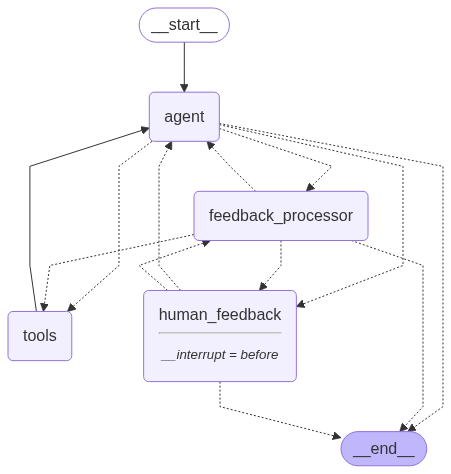

In [94]:
# Add this import at the top with your other imports
from IPython.display import Image, display


graph_image = app.get_graph().draw_mermaid_png()
    
    # Display the image
display(Image(graph_image))
    

### Initialize chatbot

In [102]:
class RoadNetworkChatBot:
    def __init__(self, verbose = True):
        self.app = app
        self.verbose = verbose
        self.schema = CACHED_SCHEMA
        self.current_config = None
        self.current_thread_id = None

        if self.verbose:
            print("Initializing chatbot with cached schema...")
            if self.schema:
                print(f"Schema loaded: {str(self.schema)[:100]}...")
            else:
                print("No cached schema available")
    
    def get_cached_schema(self):
        """Get the cached schema without making a database call"""
        return str(self.schema) if self.schema else "Schema not available"
    
    def query(self, question: str, run_name: str = None):
        """Start a new query - this will interrupt when human feedback is needed"""
        try:
            if self.verbose:
                print(f"Starting query: {question}")

            initial_state = {
                "messages": [HumanMessage(content=question)],
                "tool_calls": [],
                "_step_count": 0
            }

            # Unique thread per query to isolate memory
            self.current_thread_id = f"thr-{pd.Timestamp.now().value}"
            self.current_config = {
                "configurable": {"thread_id": self.current_thread_id}, 
                "run_name": run_name or f"traffic_query_{pd.Timestamp.now().value}",
                "tags": ["traffic-management", "neo4j"],
                "metadata": {"query_start": str(pd.Timestamp.now())},
                'recursion_limit': 30
            }

            # Use simple invoke instead of streaming to avoid duplicate processing
            try:
                result = self.app.invoke(initial_state, self.current_config)
                
                # Check if we got a final result or if we're interrupted
                if result and "messages" in result:
                    last_message = result["messages"][-1] if result["messages"] else None
                    if last_message and hasattr(last_message, 'content'):
                        return last_message.content
                
                return "Workflow completed"
                
            except Exception as e:
                if "NodeInterrupt" in str(e) or "interrupt" in str(e).lower():
                    print("🔄 Workflow interrupted - waiting for human feedback")
                    print("Use chatbot.show_current_plan() to see the response plan")
                    print("Use chatbot.continue_with_feedback('your feedback') to continue")
                    return "Workflow interrupted for human review"
                else:
                    raise e

        except Exception as e:
            if self.verbose:
                print(f"Error in query: {e}")
            return f"Error: {e}"
    
    def continue_with_feedback(self, feedback: str):
        """Continue the interrupted workflow with human feedback"""
        try:
            if not self.current_config:
                return "No active workflow to continue. Start a new query first."
            
            # Update state with feedback and continue
            state_snapshot = self.app.get_state(self.current_config)
            if not state_snapshot.next:
                return "No interrupted workflow found to continue."
            
            # Determine if it's approval or revision feedback
            is_approval = feedback.lower().strip() in ['approved', 'approve', 'yes', 'ok', 'good']
            
            updated_state = {
                **state_snapshot.values,
                "user_feedback": feedback,
                "needs_revision": not is_approval,
                "final_approved": is_approval
            }
            
            # Update the state and continue
            self.app.update_state(self.current_config, updated_state)
            
            # Continue execution
            result = self.app.invoke(None, self.current_config)
            
            if result and "messages" in result:
                last_message = result["messages"][-1] if result["messages"] else None
                if last_message and hasattr(last_message, 'content'):
                    return last_message.content
            
            return "Workflow completed"
        
        except Exception as e:
            return f"Error continuing workflow: {e}"
    
    def show_current_plan(self):
        """Display the current response plan awaiting review"""
        try:
            if not self.current_config:
                return "No active workflow. Start a new query first."
            
            state_snapshot = self.app.get_state(self.current_config)
            if not state_snapshot or not state_snapshot.values.get("messages"):
                return "No workflow state found"
            
            # Find the latest response plan
            for message in reversed(state_snapshot.values["messages"]):
                if hasattr(message, 'name') and message.name == "generate_response_plan":
                    plan = message.content
                    print("=" * 60)
                    print("CURRENT RESPONSE PLAN AWAITING REVIEW:")
                    print("=" * 60)
                    print(plan)
                    print("=" * 60)
                    print("Use chatbot.continue_with_feedback('approve') to approve")
                    print("Or chatbot.continue_with_feedback('your feedback') to request changes")
                    print("=" * 60)
                    return "Plan displayed above"  # Simple confirmation message
            
            return "No response plan found in current workflow"
            
        except Exception as e:
            return f"Error retrieving plan: {e}"

## Testing


In [103]:
# STEP 1: Initialize the chatbot
chatbot = RoadNetworkChatBot()

# STEP 2: Define an incident query
incident_query = "The event_id is 38382929, At 12:45 this morning, a multi-vehicle accident occurred on road link 17840006094278 near the junction with Elmwood Avenue Motorway. Two lanes are currently blocked, causing a queue of approximately 3000 meters. Emergency services are on site, and the incident has been active for 35 minutes. The severity is high due to the number of vehicles involved and the impact on traffic flow. Additional hazards include spilled fuel and debris on the road. Weather conditions are foggy, contributing to low visibility. Traffic volume is high due to rush hour."

# STEP 3: Start the workflow - it will interrupt when human feedback is needed
print("Starting incident management workflow...")
result = chatbot.query(incident_query)

Initializing chatbot with cached schema...
Schema loaded: Node properties:
event_record {id: INTEGER, event_sub_type_id: FLOAT, on_scene_time: FLOAT, event_se...
Starting incident management workflow...
Starting query: The event_id is 38382929, At 12:45 this morning, a multi-vehicle accident occurred on road link 17840006094278 near the junction with Elmwood Avenue Motorway. Two lanes are currently blocked, causing a queue of approximately 3000 meters. Emergency services are on site, and the incident has been active for 35 minutes. The severity is high due to the number of vehicles involved and the impact on traffic flow. Additional hazards include spilled fuel and debris on the road. Weather conditions are foggy, contributing to low visibility. Traffic volume is high due to rush hour.
Event 38382929: New event detected, generating response plan
Event 38382929: New event detected, generating response plan
Response plan generated - routing to human review
Response plan generated - routi

In [104]:
chatbot.show_current_plan()

CURRENT RESPONSE PLAN AWAITING REVIEW:
Based on the comprehensive guidelines and incident context, here's the detailed Traffic Management Response Plan:

{
    "plan_type": "Traffic Management Plan",
    "priority": "High",
    "estimated_duration": "45 minutes",
    "traffic_management_actions": [
        {
            "eqt_no": "E11DMSG04S",
            "message_line_1": "MAJOR ACCIDENT",
            "message_line_2": "SLOW DOWN NOW",
            "display_duration": "45",
            "distance": "86",
            "psychological_rationale": "Immediate proximity requires urgent, direct language to trigger instant behavioral change",
            "behavioral_goal": "Force immediate speed reduction and heightened awareness",
            "urgency_level": "High",
            "reasoning": "Closest VMS requires most aggressive messaging to prevent secondary incidents"
        },
        {
            "eqt_no": "E11DMSG05S", 
            "message_line_1": "ACCIDENT AHEAD",
            "message

'Plan displayed above'

In [105]:
chatbot.continue_with_feedback("Increase the distance search for VMS to 10000 and use all the VMS found to create a new response plan")


🔄 Feedback Processor: Processing feedback: Increase the distance search for VMS to 10000 and use all the VMS found to create a new response pla...
Response plan generated - routing to human review
Response plan generated - routing to human review


[]

In [106]:
chatbot.show_current_plan()

CURRENT RESPONSE PLAN AWAITING REVIEW:
I'll generate a comprehensive response plan based on the provided context and guidelines. Here's the detailed traffic management plan:

{
    "plan_type": "Traffic Management Plan",
    "priority": "High",
    "estimated_duration": "45 minutes",
    "traffic_management_actions": [
        {
            "eqt_no": "E11DMSG06S",
            "message_line_1": "MAJOR ACCIDENT",
            "message_line_2": "EXPECT LONG DELAYS",
            "display_duration": "45",
            "distance": "9847",
            "psychological_rationale": "Early warning to reduce cognitive load and prepare drivers",
            "behavioral_goal": "Mental preparation for potential route changes",
            "urgency_level": "Low",
            "reasoning": "Far from incident, provides initial awareness without causing panic"
        },
        {
            "eqt_no": "E11DMSG03N",
            "message_line_1": "SLOW TRAFFIC",
            "message_line_2": "ACCIDENT AHEAD",

'Plan displayed above'

In [107]:
chatbot.continue_with_feedback("approve")

Storage completed successfully - ending workflow


[]